<a href="https://colab.research.google.com/github/rishabh1024/langgraph-colab-notebooks/blob/main/TaskMaestro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -qU langchain-openai langgraph langgraph-checkpoint-sqlite langgraph-sdk wikipedia langchain-tavily trustcall

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.6/151.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.7/216.7 kB 18.9 MB/s eta 0:00:00


In [ ]:
!pip install -qU requests==2.32.4 langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.0 MB/s eta 0:00:00


In [ ]:
import getpass
import os
from google.colab import userdata
import google.generativeai as genai

openrouter_api_key = userdata.get('OPENROUTER_API_KEY')
tavily_api_key = userdata.get('TAVILY_API_KEY')

api_key = userdata.get("LANGCHAIN_API_KEY")
if not api_key:
    raise ValueError("No LANGSMITH_API_KEY found in Colab userdata. Please set it first.")

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "task-maestro"
os.environ["LANGCHAIN_API_KEY"] = api_key
os.environ["LANGSMITH_API_KEY"] = api_key
os.environ["TAVILY_API_KEY"] = tavily_api_key
# Replace "my-langchain-project" with the name you want for your project in LangSmith
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage

from langgraph.graph import START, END, StateGraph, MessagesState

# "nvidia/nemotron-nano-9b-v2:free"
# "deepseek/deepseek-chat-v3.1:free"

model = ChatOpenAI(
                  model="openai/gpt-5",
                  api_key=openrouter_api_key,
                  base_url="https://openrouter.ai/api/v1",
                  temperature=0.1
                  )

In [ ]:
from pydantic import BaseModel, Field

class Memory(BaseModel):
  content: str = Field(description="The main content of the the memory. For example: User expressed interest in learning about French.")

class MemoryCollection(BaseModel):
  memories: list[Memory] = Field(description="List of memories of the user.")

In [ ]:
 from trustcall import create_extractor


class Spy:

  def __init__(self):
    self.called_tools = []

  def __call__(self, runs):
    # Collect the tools calls made by the extractor
    q = [runs]
    while q:
      run = q.pop()
      if run.child_runs:
        q.extend(run.child_runs)
      if run.run_type == "chat_model":
        self.called_tools.append(run.outputs["generations"][0][0]["message"]["kwargs"]["tool_calls"]
                                 )

spy = Spy()

trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    enable_inserts=True
)

trustcall_extractor_with_toolcall_tracing = trustcall_extractor.with_listeners(on_end=spy)

In [ ]:
from typing import TypedDict, Literal

class UpdatedMemory(TypedDict):
  """Decision on what memory type to update"""
  update_type: Literal['user', 'todo', 'instructions']

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

instruction = """Extract memories from the following conversation"""

# Conversation
conversation = [HumanMessage(content="Hey, my name is Rishi! I am learning langgraph"),
                AIMessage(content="Nice to meet you, Rishi! It's great to know you're learning Agent Orchestration Framework called Langgraph! What else is on your mind?"),
                HumanMessage(content="I am actually planning to move back to India now!")]

# Invoke the extractor
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=instruction)] + conversation})

In [ ]:
for m in result["messages"]:
  m.pretty_print()

In [ ]:
# Responses contain the memories that adhere to the schema
for m in result["responses"]:
    print(m)


In [ ]:
updated_conversation = [HumanMessage(content="I might think about my Japan trip later!"),]

# Update the instruction
system_msg = """Update existing memories and create new ones based on the following conversation:"""

# We'll save existing memories, giving them an ID, key (tool name), and value
tool_name = "Memory"
existing_memories = [(str(i), tool_name, memory.model_dump()) for i, memory in enumerate(result["responses"])] if result["responses"] else None
existing_memories

In [ ]:
# Invoke the extractor with our updated conversation and existing memories
result = trustcall_extractor_with_toolcall_tracing.invoke({"messages": updated_conversation,
                                                        "existing": existing_memories})

In [ ]:
# Metadata contains the tool call
for m in result["response_metadata"]:
    print(m)

In [ ]:
# Messages contain the tool calls
for m in result["messages"]:
    m.pretty_print()


In [ ]:
# Parsed responses
for m in result["responses"]:
    print(m)


In [ ]:
spy.called_tools

#### Memory Agent

In [ ]:
def extract_tool_info(tool_calls, schema_name="Memory"):
    """Extract information from tool calls for both patches and new memories.

    Args:
        tool_calls: List of tool calls from the model
        schema_name: Name of the schema tool (e.g., "Memory", "ToDo", "Profile")
    """

    # Initialize list of changes
    changes = []

    if not tool_calls: # Add a check for empty tool_calls
        return "No tool calls made."

    for call_group in tool_calls:
        if not call_group: # Add a check for empty call_group
            continue
        for call in call_group:
            if call.get('name') == 'PatchDoc': # Use .get() for safe access
                args = call.get('args')
                if args and 'patches' in args and args['patches']: # Check if args and patches exist and patches is not empty
                    changes.append({
                        'type': 'update',
                        'doc_id': args.get('json_doc_id'), # Use .get() for safe access
                        'planned_edits': args.get('planned_edits'), # Use .get() for safe access
                        'value': args['patches'][0].get('value') # Use .get() for safe access on the patch
                    })
            elif call.get('name') == schema_name: # Use .get() for safe access
                changes.append({
                    'type': 'new',
                    'value': call.get('args') # Use .get() for safe access
                })

    # Format results as a single string
    result_parts = []
    if not changes:
        return f"No {schema_name} or PatchDoc tool calls found."

    for change in changes:
        if change['type'] == 'update':
            result_parts.append(
                f"Document {change.get('doc_id', 'Unknown')} updated:\n" # Use .get() with default
                f"Plan: {change.get('planned_edits', 'Unknown')}\n" # Use .get() with default
                f"Added content: {change.get('value', 'Unknown')}" # Use .get() with default
            )
        else:
            result_parts.append(
                f"New {schema_name} created:\n"
                f"Content: {change.get('value', 'Unknown')}" # Use .get() with default
            )

    return "\n\n".join(result_parts)

In [ ]:
from typing import TypedDict, Literal

class UpdatedMemory(TypedDict):
  """Decision on what memory type to update"""
  update_type: Literal['user', 'todo', 'instructions']

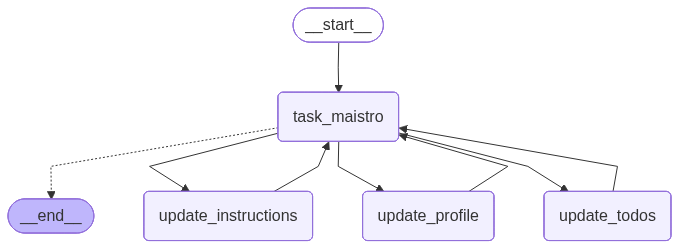

In [ ]:
from threading import current_thread
import uuid
from IPython.display import Image, display

from datetime import datetime
from trustcall import create_extractor
from typing import Optional
from pydantic import BaseModel, Field

from langchain_core.runnables import RunnableConfig
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore

class UserProfile(BaseModel):
  """This is the profile of the user. The user here for this instance is me"""

  name: Optional[str] = Field(description="The name of the user", default="None")
  location: Optional[str] = Field(description="The location of the user", default="None")
  age: Optional[int] = Field(description="The age of the user", default=0)
  job: Optional[str] = Field(description="The job of the user", default="None")
  connections: Optional[list[str]] = Field(description="The connections of the user such as the familty members, friends and co-workers", default=[])
  interests: Optional[list[str]] = Field(description="The interests of the user", default=[])
  goals: Optional[list[str]] = Field(description="The goals of the user", default=[])


class ToDo(BaseModel):
  """ This is the schema for a ToDo list"""
  task: Optional[str] = Field(
      description="The task that has to be completed")
  time_to_complete: Optional[int] = Field(
      description="The time it takes to complete the task in minutes")
  deadline: Optional[datetime] = Field(
      description="When does the task have to be completed by",
      default=None)
  solutions: list[str] = Field(
      description="""List of specific, actionable solutions (e.g. specific ideas,
      service providers, or concrete options relevant to the task)""",
      min_items=1,
      default_factory=list
  )
  status: Literal['not started', "in progress", "done", "archived"] = Field(
      description="The status of the task",
      default="not started"
  )


profile_extractor = create_extractor(
    model,
    tools=[UserProfile],
    tool_choice="UserProfile"
)

# Chatbot instruction for choosing what to update and what tools to call
MODEL_SYSTEM_MESSAGE = """You are a helpful chatbot.

You are designed to be a companion to a user, helping them keep track of their ToDo list.

You have a long term memory which keeps track of three things:
1. The user's profile (general information about them)
2. The user's ToDo list
3. General instructions for updating the ToDo list

Here is the current UserProfile (may be empty if no information has been collected yet):
<user_profile>
{user_profile}
</user_profile>

Here is the current ToDo List (may be empty if no tasks have been added yet):
<todo>
{todo}
</todo>

Here are the current user-specified preferences for updating the ToDo list (may be empty if no preferences have been specified yet):
<instructions>
{instructions}
</instructions>

Here are your instructions for reasoning about the user's messages:

1. Reason carefully about the user's messages as presented below.

2. Decide whether any of the your long-term memory should be updated:
- If personal information was provided about the user, update the user's profile by calling UpdateMemory tool with type `user`
- If tasks are mentioned, update the ToDo list by calling UpdateMemory tool with type `todo`
- If the user has specified preferences for how to update the ToDo list, update the instructions by calling UpdateMemory tool with type `instructions`

3. Tell the user that you have updated your memory, if appropriate:
- Do not tell the user you have updated the user's profile
- Tell the user them when you update the todo list
- Do not tell the user that you have updated instructions

4. Err on the side of updating the todo list. No need to ask for explicit permission.

5. Respond naturally to user user after a tool call was made to save memories, or if no tool call was made."""

# Trustcall instruction
TRUSTCALL_INSTRUCTION = """Reflect on following interaction.

Use the provided tools to retain any necessary memories about the user.

Use parallel tool calling to handle updates and insertions simultaneously.

System Time: {time}"""

# Instructions for updating the ToDo list
CREATE_INSTRUCTIONS = """Reflect on the following interaction.

Based on this interaction, update your instructions for how to update ToDo list items.

Use any feedback from the user to update how they like to have items added, etc.

Your current instructions are:

<current_instructions>
{current_instructions}
</current_instructions>"""


def task_maistro(state: MessagesState, config: RunnableConfig, store: BaseStore) -> MessagesState:

  """Load memories from the store ana use them to personalize the chatbot's response"""

  user_id = config["configurable"]["user_id"]


  # Retreive profile memory from the store
  namespace = ("profile", user_id)
  memories = store.search(namespace)

  if memories:
    user_profile = memories[0].value
  else:
    user_profile = None

  # Retrieve task memory from the store
  namespace = ("todo", user_id)
  memories = store.search(namespace)

  todo = "\n".join(f"{mem.value}" for mem in memories)

  # Retrieve instruction memory from the store
  namespace = ("instructions", user_id)
  memories = store.search(namespace)

  if memories:
    instructions = memories[0].value
  else:
    instructions = ""

  system_message = MODEL_SYSTEM_MESSAGE.format(
      user_profile=user_profile,
      todo=todo,
      instructions=instructions
  )

  response = model.bind_tools([UpdatedMemory], parallel_tool_calls=False).invoke(
      [SystemMessage(content=system_message)] + state["messages"]
  )

  return {"messages": [response]}


def update_profile(state: MessagesState, config: RunnableConfig, store: BaseStore) -> MessagesState:
  """Reflect on the chat history and update the memory collection"""

  # Get the user_id from the config
  user_id = config["configurable"]["user_id"]

  # Define the namespace for the memories
  namespace = ("profile", user_id)

  # Retrieve the most recent memories for the context
  existing_items = store.search(namespace)

  # Format the existing memories for context
  tool_name = "UserProfile"

  existing_memories =  ([(existing_item.key, tool_name, existing_item.value)
   for existing_item in existing_items] if existing_items else None)

  # Merge the chat history and the instruction
  TRUSTCALL_INSTRUCTION_FORMATTED = TRUSTCALL_INSTRUCTION.format(
      time=datetime.now().isoformat())
  updated_messages = list(merge_message_runs(
      messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)]
      + state["messages"][:-1]))

  # Invoke the extractor
  result = profile_extractor.invoke({
      "messages": updated_messages,
      "existing": existing_memories
  })

  # Save the memories from the trustcall to the store
  for r, rmeta in zip(result["responses"], result["response_metadata"]):
    store.put(namespace,
              rmeta.get("json_doc_id", str(uuid.uuid4())),
              r.model_dump(mode="json"),
    )

  tool_calls = state["messages"][-1].tool_calls
  print(f"Tool Calls in {update_profile.__name__}: {tool_calls}")

  if tool_calls:
    return {"messages": [{"role": "tool", "content": "updated_profile",
                        "tool_call_id": tool_calls[0]['id']}]}
  else:
    return {"messages": [{"role": "tool", "content": "updated_profile",
                        "tool_call_id": None}]}

def update_todos(state: MessagesState, config: RunnableConfig, store: BaseStore) -> MessagesState:
  """Reflect on the chat history and update the memory collection"""

  # Get the user_id from the config
  user_id = config["configurable"]["user_id"]

  # Define the namespace for the memories
  namespace = ("todo", user_id)

  # Retrieve the most recent memories for the context
  existing_items = store.search(namespace)

  # Format the existing memories for context
  tool_name = "ToDo"

  existing_memories =  ([(existing_item.key, tool_name, existing_item.value)
  for existing_item in existing_items] if existing_items else None)

  # Merge the chat history and the instruction
  TRUSTCALL_INSTRUCTION_FORMATTED = TRUSTCALL_INSTRUCTION.format(
      time=datetime.now().isoformat())
  updated_messages = list(merge_message_runs(
      messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)]
      + state["messages"][:-1]))


  # Initialize the spy for the visibility into the tool calls made by Trustcall
  spy = Spy()

  # Create the Trustcall extractor for updating the todo list
  todo_extractor = create_extractor(
      model,
      tools = [ToDo],
      tool_choice=tool_name,
      enable_inserts=True
  ).with_listeners(on_end=spy)

  # Invoke the extractor
  result = todo_extractor.invoke({
      "messages": updated_messages,
      "existing": existing_memories
  })

  # Save the memories from the Trustcall to the store
  for r, rmeta in zip(result["responses"], result["response_metadata"]):
    store.put(namespace,
              rmeta.get("json_doc_id", str(uuid.uuid4())),
              r.model_dump(mode="json"),
    )

  # Respond to the tool call made in task_Maistro, confirming the update
  tool_calls = state['messages'][-1].tool_calls
  print(f"Tool Calls in {update_todos.__name__}: {tool_calls}")
  todo_updated_messages = extract_tool_info(spy.called_tools, tool_name)
  if tool_calls:
      return {"messages": [{"role": "tool", "content": todo_updated_messages,
                        "tool_call_id": tool_calls[0]['id']}]}
  else:
      return {"messages": [{"role": "tool", "content":todo_updated_messages,
                          "tool_call_id": None}]}



def update_instructions(state: MessagesState, config: RunnableConfig,
                        store: BaseStore) -> MessagesState:
    """Reflect on the chat history and update the memory collection"""

    # Reflect the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("instructions", user_id)

    # Retrieve the most recent memories for the context
    existing_memory = store.get(namespace, "user_instructions")

    # Format the memory in the system prompt
    system_message = CREATE_INSTRUCTIONS.format(
        current_instructions=existing_memory.value if existing_memory
        else None
    )

    new_memory = model.invoke(
        [SystemMessage(
            content=system_message)]+state["messages"][:-1] +
        [HumanMessage(
            content="Please update the instructions based on the conversation")]
        )

    key = 'user_instructions'
    store.put(namespace, key, {"memory": new_memory.content})

    tool_calls = state["messages"][-1].tool_calls
    print(f"Tool Calls in {update_instructions.__name__}: {tool_calls}")
    if tool_calls:
      return {"messages": [{"role": "tool", "content": "updated_instructions",
                          "tool_call_id": tool_calls[0]['id']}]}
    else:
      return {"messages": [{"role": "tool", "content": "updated_instructions",
                          "tool_call_id": None}]}

# Conditional edge
def route_message(state: MessagesState, config: RunnableConfig, store: BaseStore) -> Literal[END, "update_todos", "update_instructions", "update_profile"]:

    """Reflect on the memories and chat history to decide whether to update the memory collection."""
    message = state['messages'][-1]
    if len(message.tool_calls) == 0:
        return END
    else:
        tool_call = message.tool_calls[0]
        if tool_call['args']['update_type'] == "user":
            return "update_profile"
        elif tool_call['args']['update_type'] == "todo":
            return "update_todos"
        elif tool_call['args']['update_type'] == "instructions":
            return "update_instructions"
        else:
            raise ValueError


builder = StateGraph(MessagesState)

builder.add_node(task_maistro)
builder.add_node(update_todos)
builder.add_node(update_instructions)
builder.add_node(update_profile)

builder.add_edge(START, "task_maistro")
builder.add_edge("task_maistro", "update_todos")
builder.add_edge("task_maistro", "update_instructions")
builder.add_edge("task_maistro", "update_profile")
builder.add_conditional_edges("task_maistro", route_message)
builder.add_edge("update_todos", "task_maistro")
builder.add_edge("update_instructions", "task_maistro")
builder.add_edge("update_profile", "task_maistro")


# Store the the long-term (across-thread) memory
long_term_memory = InMemoryStore()

# Store te short term memory (within-thread)
short_term_memory = MemorySaver()

# Compile the graph with the two memories
graph = builder.compile(store=long_term_memory, checkpointer=short_term_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
input_messages = [HumanMessage(content="Hi! My name is Rishi!")]

config = {
    "configurable": {
        "user_id": "1",
        "thread_id": "1"
    }
}

response = graph.invoke({"messages": input_messages}, config=config)
print(response.content)

Tool Calls in update_profile: [{'name': 'UpdatedMemory', 'args': {'update_type': 'user'}, 'id': 'call_8qkH2m5sbQKR8265CJEQM3yI', 'type': 'tool_call'}]
Tool Calls in update_todos: [{'name': 'UpdatedMemory', 'args': {'update_type': 'user'}, 'id': 'call_8qkH2m5sbQKR8265CJEQM3yI', 'type': 'tool_call'}]
Tool Calls in update_instructions: [{'name': 'UpdatedMemory', 'args': {'update_type': 'user'}, 'id': 'call_8qkH2m5sbQKR8265CJEQM3yI', 'type': 'tool_call'}]
Tool Calls in update_profile: []
Tool Calls in update_todos: []
Tool Calls in update_instructions: []


KeyError: 'tool_call_id'